In [2]:
import csv
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('thesis__data.csv', usecols = ['YEAR', 'AGE', 'MORTSTAT', 'MORTDODY', 'POVERTY'])

In [4]:
# remove what has to be removed
df = df[(df['MORTSTAT'] == 1) | (df['MORTSTAT'] == 2)]

# define year of birth
df['YEAR_BIRTH'] = df['YEAR'] - df['AGE']

In [5]:
# computes the average number of people at each age over years
def avr_P_i(df, years, age_min, age_max):
    
    standardization_df = pd.DataFrame(index=years, columns=range(age_min, age_max + 1))
    
    for year in years:
        df_use = df[(df['MORTDODY'] >= year) & (df['YEAR'] <= year)].copy()

        # define age of these people in year 
        df_use['AGE_year'] = year - df_use['YEAR_BIRTH']
        df_use = df_use[df_use['AGE_year'] <= age_max]

        # count occurrences of each age for the year
        age_count = df_use['AGE_year'].value_counts().reindex(range(age_min, age_max + 1), fill_value=0)

        # assign the counts to the standardization DataFrame
        standardization_df.loc[year] = age_count.values
        
    mean_count = standardization_df.mean()
    
    return mean_count 

In [6]:
# pre-selection
age_min = 18
age_max = 80

In [7]:
# POVERTY

In [8]:
# remove NaN samples
df_poverty = df.dropna(subset=['POVERTY'])

# remove NIU responces
df_poverty = df_poverty[(df_poverty['POVERTY'] > 0) & (df_poverty['POVERTY'] < 38)].copy()

# we need to group codes because different years use different encodings
df_poverty['POVERTY'] = df_poverty['POVERTY'].replace([10, 11, 12, 13, 14], 1)       # <1
df_poverty['POVERTY'] = df_poverty['POVERTY'].replace([20, 21, 22, 23, 24, 25], 2)   # [1,2)
df_poverty['POVERTY'] = df_poverty['POVERTY'].replace([31, 32], 3)                   # [2,3)
df_poverty['POVERTY'] = df_poverty['POVERTY'].replace([33, 34], 4)                   # [3,4)
df_poverty['POVERTY'] = df_poverty['POVERTY'].replace([35, 36], 5)                   # [4,5)
df_poverty['POVERTY'] = df_poverty['POVERTY'].replace([37], 6)                       # >=5

# define populations
populations = sorted(df_poverty['POVERTY'].unique())

# initialize DataFrame to store SMR (standardized mortality rates) for each year
years = list(range(df_poverty['YEAR'].min(), df_poverty['YEAR'].max()+2))

# df for ASMR
smr_pov = pd.DataFrame(index=years, columns=populations) 

# track agining of population
age_avr = pd.DataFrame(index=years, columns=populations) 

mean_count = avr_P_i(df_poverty, years, age_min, age_max)

for year in years:
    # people who were alive at the beginning of year  
    df_year = df_poverty[(df_poverty['MORTDODY'] >= year) & (df_poverty['YEAR'] <= year)].copy()

    # define age of these people in year 
    df_year['AGE_year'] = year - df_year['YEAR_BIRTH']
    df_year = df_year[df_year['AGE_year'] <= age_max]
    
    # age counts 
    age_counts = []
    for age in range(age_min, age_max + 1):
        age_counts.append(df_year[df_year['AGE_year'] == age].shape[0])
   
    for population in populations:
        # work with one population at the time
        df_year_population  = df_year[df_year['POVERTY'] == population].copy()
        
        age_avr.at[year, population] = (df_year_population['AGE_year'].mean())
        
        # counts:
        count_all = []
        count_dead = []
        for age in range(age_min, age_max + 1):
            total_count = df_year_population[df_year_population['AGE_year'] == age].shape[0]
            dead_count = df_year_population[(df_year_population['MORTDODY'] == year) & (df_year_population['AGE_year'] == age)].shape[0]
            
            count_all.append(total_count)
            count_dead.append(dead_count)
        
        mr_per_age = [dead / total if total > 0 else 0 for dead, total in zip(count_dead, count_all)]
       
        smr_pov.at[year, population] = sum([a*b for a,b in zip(mr_per_age, mean_count)]) / sum(mean_count)  

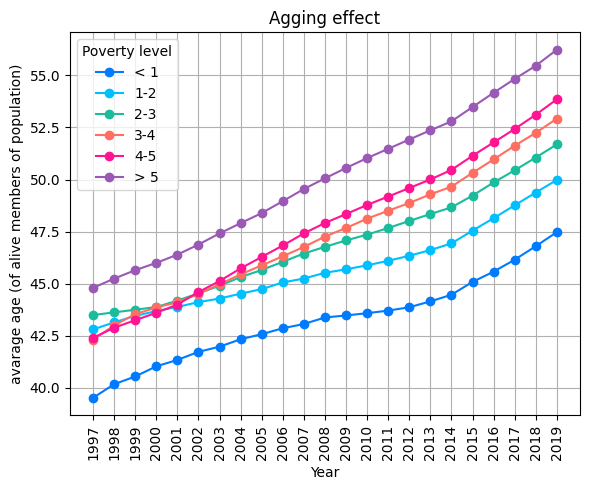

In [9]:
plt.figure(figsize=(6, 5))
labels = {1: '< 1', 2: '1-2', 3: '2-3', 4: '3-4', 5: '4-5', 6: '> 5'}
colors = ['#007BFF', '#00BFFF', '#1ABC9C', '#FF6F61', '#FF1493', '#9B59B6']

for i, population in enumerate(populations):
    plt.plot(age_avr.index, age_avr[population], marker='o', label=labels[population], color=colors[i])

plt.title('Agging effect')
plt.xlabel('Year')
plt.ylabel('avarage age (of alive members of population)')
plt.xticks(smr_pov.index, rotation=90)  
plt.legend(title='Poverty level')
plt.grid()
plt.tight_layout()
plt.savefig('agging_poverty.jpg', format='jpg')
plt.show()

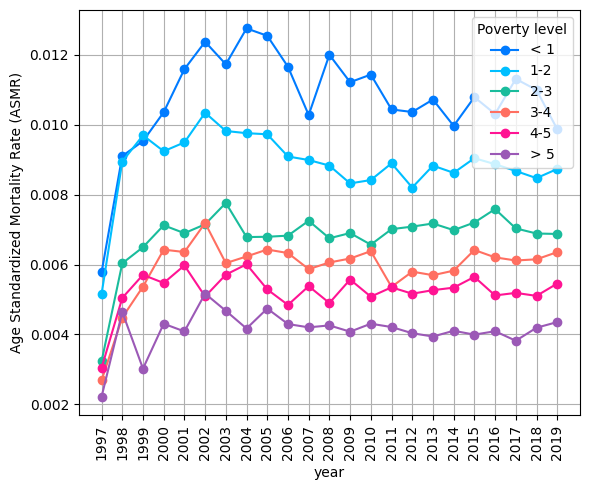

In [10]:
plt.figure(figsize=(6, 5))

for i, population in enumerate(populations):
    plt.plot(smr_pov.index, smr_pov[population], marker='o', label=labels[population], color=colors[i])

plt.xlabel('year')
plt.ylabel('Age Standardized Mortality Rate (ASMR)')
plt.xticks(smr_pov.index, rotation=90)  
plt.legend(title='Poverty level')
plt.grid()
plt.tight_layout()
plt.savefig('smr_poverty.jpg', format='jpg')
plt.show()

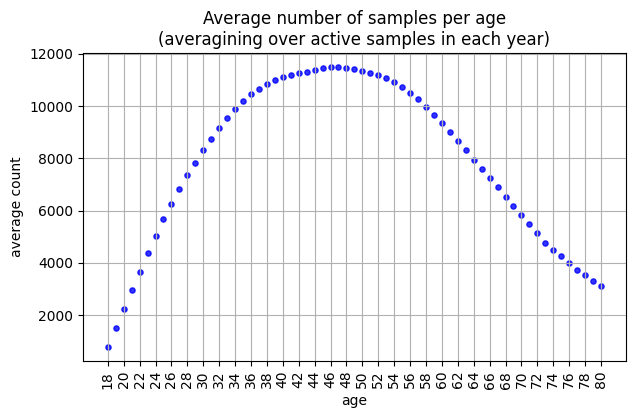

In [11]:
# scatter plot for average counts by age
plt.figure(figsize=(7, 4))
plt.scatter(mean_count.index, mean_count.values, color='blue', alpha=0.8, s=14)
plt.title('Average number of samples per age\n(averagining over active samples in each year)')
plt.xlabel('age')
plt.ylabel('average count')
plt.xticks(range(age_min, 81, 2), rotation=90) 
plt.grid()
plt.savefig('avr_ppl_count_poverty.jpg', format='jpg')
plt.show()

In [12]:
# use smr for years after 2000
smr_2000  = smr_pov[smr_pov.index >= 2000]
# compute average per population
smr_mean = smr_2000.mean()

# define custom labels for x-axis
label_list = [labels[i+1] for i in range(len(labels))]

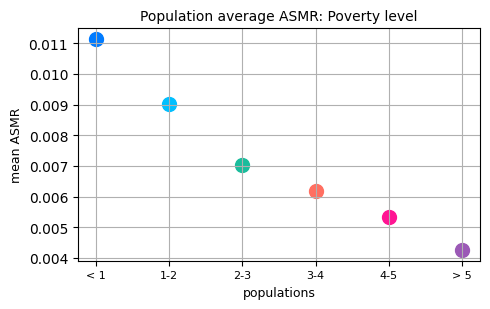

In [13]:
# --- plot ---
plt.figure(figsize=(5, 3.2))

# loop through the points and color them
for i, (x, y) in enumerate(zip(smr_mean.index, smr_mean.values)):
    plt.scatter(x, y, color=colors[i], s=100)

plt.title('Population average ASMR: Poverty level', fontsize=10)
plt.xlabel('populations', fontsize=9)
plt.ylabel('mean ASMR', fontsize=9)
plt.xticks(smr_mean.index, label_list, rotation=0, fontsize=8)  
plt.xticks(fontsize=8) 
plt.tight_layout()  
plt.grid(True)  
plt.savefig('avr_amr_poverty.jpg', format='jpg')
plt.show()